In [5]:
import gdxpds
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# GDX 파일 경로를 지정합니다.
gdx_file_path = 'BAU_Results_GTAP11c_new.gdx'

# GDX 파일을 데이터프레임 딕셔너리로 불러옵니다.
gdx_data = gdxpds.to_dataframes(gdx_file_path)

# 불러온 데이터 확인
print("GDX 파일에 포함된 요소들:", list(gdx_data.keys()))

GDX 파일에 포함된 요소들: ['valA_VA', 'valC', 'valCAB', 'valCABX', 'valCG', 'valCI', 'valCE', 'valCMIN', 'valCTH', 'valCTH_REAL', 'valDD', 'valDEP', 'valDI', 'valDE', 'valDIT', 'valDS', 'valDS_I', 'vale', 'valEX', 'valEXT', 'valG', 'ValG_REAL', 'valGDP_BP', 'valGDP_BP_REAL', 'valGDP_BP_W', 'valGDP_BP_W_REAL', 'valGDP_FD', 'valGDP_IB', 'valGDP_MP', 'valGDP_MP_REAL', 'valIM', 'valIMT', 'valIND', 'valINV', 'valIR', 'valIT', 'valIT_REAL', 'valKD', 'valKDC', 'valKS', 'valLD', 'valLDC', 'valLS', 'valLST', 'valMRGN', 'valP', 'valPC', 'valPCI', 'valPCE', 'valPD', 'valPE', 'valPET', 'valphi', 'valPIXCON', 'valPIXCON2', 'valPIXGDP', 'valPIXGDP_W', 'valPIXGVT', 'valPIXINV', 'valPK', 'valPL', 'valPM', 'valPMT', 'valPP', 'valPT', 'valPVA', 'valPKLE', 'valPWM', 'valPWMG', 'valPWX', 'valQ', 'valR', 'valRC', 'valRTI', 'valSG', 'valSH', 'valsh0', 'valsh1', 'valSROW', 'valTDH', 'valTIC', 'valTICT', 'valTIK', 'valTIKT', 'valTIM', 'valTIMT', 'valTIP', 'valTIPT', 'valTIW', 'valTIWT', 'valTIX', 'valTIXT', 'valTPRCTS

In [6]:
# 한글 폰트 설정 (Mac의 경우 'AppleGothic', Windows의 경우 'Malgun Gothic' 등)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지

## 가계 소비량 분석

In [15]:
valC_df = gdx_data['valC']

In [18]:
korea_data

,I,Z,TIME,SCEN,Value
0,01_AGRICULT,01_KOR,2019,BAU,1.361031
1,01_AGRICULT,01_KOR,2020,BAU,1.377792
2,01_AGRICULT,01_KOR,2021,BAU,1.435662
3,01_AGRICULT,01_KOR,2022,BAU,1.473837
4,01_AGRICULT,01_KOR,2023,BAU,1.503227
...,...,...,...,...,...
11995,23_SER,01_KOR,2046,BAU,72.023941
11996,23_SER,01_KOR,2047,BAU,72.325183
11997,23_SER,01_KOR,2048,BAU,72.620505
11998,23_SER,01_KOR,2049,BAU,72.914594


In [16]:
korea_data = valC_df[valC_df['Z'].str.contains('01_KOR')].copy()

In [21]:
korea_data['TIME'] = korea_data['TIME'].astype(int)
korea_data = korea_data.sort_values(by='TIME')

In [28]:
pivoted_data = korea_data.pivot_table(index='TIME', columns='I', values='Value', aggfunc='sum')

# 피벗 후 결측치(NaN)가 있다면 0으로 채워줍니다. (그래프 깨짐 방지)
pivoted_data = pivoted_data.fillna(0)

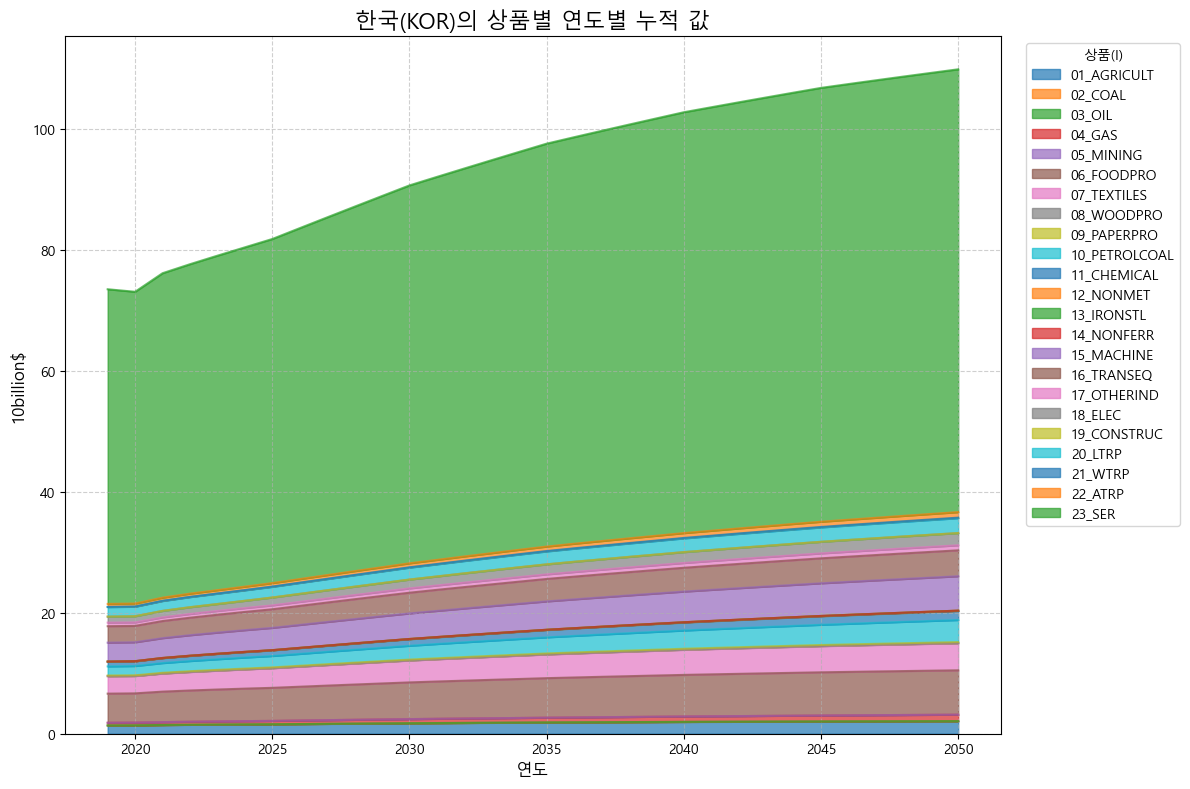

피벗된 데이터 (그래프 생성용):
I     01_AGRICULT   02_COAL    03_OIL    04_GAS  05_MINING  06_FOODPRO  \
TIME                                                                     
2019     1.361031  0.008147  0.000009  0.441530   0.002193    4.812295   
2020     1.377792  0.008408  0.000010  0.450614   0.002256    4.832671   
2021     1.435662  0.008742  0.000010  0.471252   0.002322    5.041124   
2022     1.473837  0.009197  0.000011  0.496349   0.002462    5.165454   
2023     1.503227  0.009671  0.000011  0.521896   0.002562    5.269876   
2024     1.529969  0.009897  0.000011  0.543444   0.002647    5.368201   
2025     1.555805  0.010263  0.000012  0.551640   0.002719    5.464478   
2026     1.589745  0.010717  0.000012  0.579812   0.002839    5.586833   
2027     1.623747  0.011215  0.000013  0.607187   0.002951    5.708728   
2028     1.657378  0.011642  0.000013  0.631258   0.003058    5.829196   
2029     1.690690  0.012091  0.000014  0.656098   0.003162    5.948442   
2030     1.723780  

In [31]:
# 4. 시각화
# 한글 폰트 설정 (Mac: 'AppleGothic', Windows: 'Malgun Gothic')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False # 마이너스 부호 깨짐 방지

# stacked=True 옵션이 누적 그래프를 만드는 핵심입니다.
pivoted_data.plot(kind='area', stacked=True, figsize=(12, 8), alpha=0.7)

plt.title('한국(KOR)의 상품별 연도별 누적 값', fontsize=16)
plt.xlabel('연도', fontsize=12)
plt.ylabel('10billion$', fontsize=12)
plt.legend(title='상품(I)', bbox_to_anchor=(1.02, 1), loc='upper left') # 범례를 그래프 바깥에 표시
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout() # 레이아웃 최적화

plt.show()

# 피벗된 데이터 확인
print("피벗된 데이터 (그래프 생성용):")
print(pivoted_data)